In [64]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, '../src')

from simcore.common.data_logger import DataLogger

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

In [65]:
# --- Config ---
TRIAL_PATH = '../log/experimental'   # change to your trial

# Load all bundles
bundles = DataLogger.load_all(TRIAL_PATH)

print(f"Found bundles: {list(bundles.keys())}")
for name, data in bundles.items():
    signals = [k for k in data.keys() if k != 'timestamps']
    print(f"  {name}: {len(data['timestamps'])} samples | signals: {signals}")

# Helper — relative timestamps in seconds
def t(bundle):
    ts = bundle['timestamps']
    return ts - ts[0]

Found bundles: ['box', 'target', 'arm', 'ctrl_arm', 'table']
  box: 2234 samples | signals: ['pos', 'q', 'qd', 'qdd', 'quat']
  target: 2234 samples | signals: ['pos', 'quat']
  arm: 2234 samples | signals: ['base_pos', 'base_quat', 'ctrl', 'q', 'qd', 'qdd', 'tau']
  ctrl_arm: 2233 samples | signals: ['Fff', 'cartesian_mass', 'f_ext', 'f_internal', 'mode', 'q', 'q_target', 'qd', 'tau', 'tau_gravity', 'x_current', 'x_target', 'xd_current', 'xd_target']
  table: 2234 samples | signals: ['pos', 'quat']


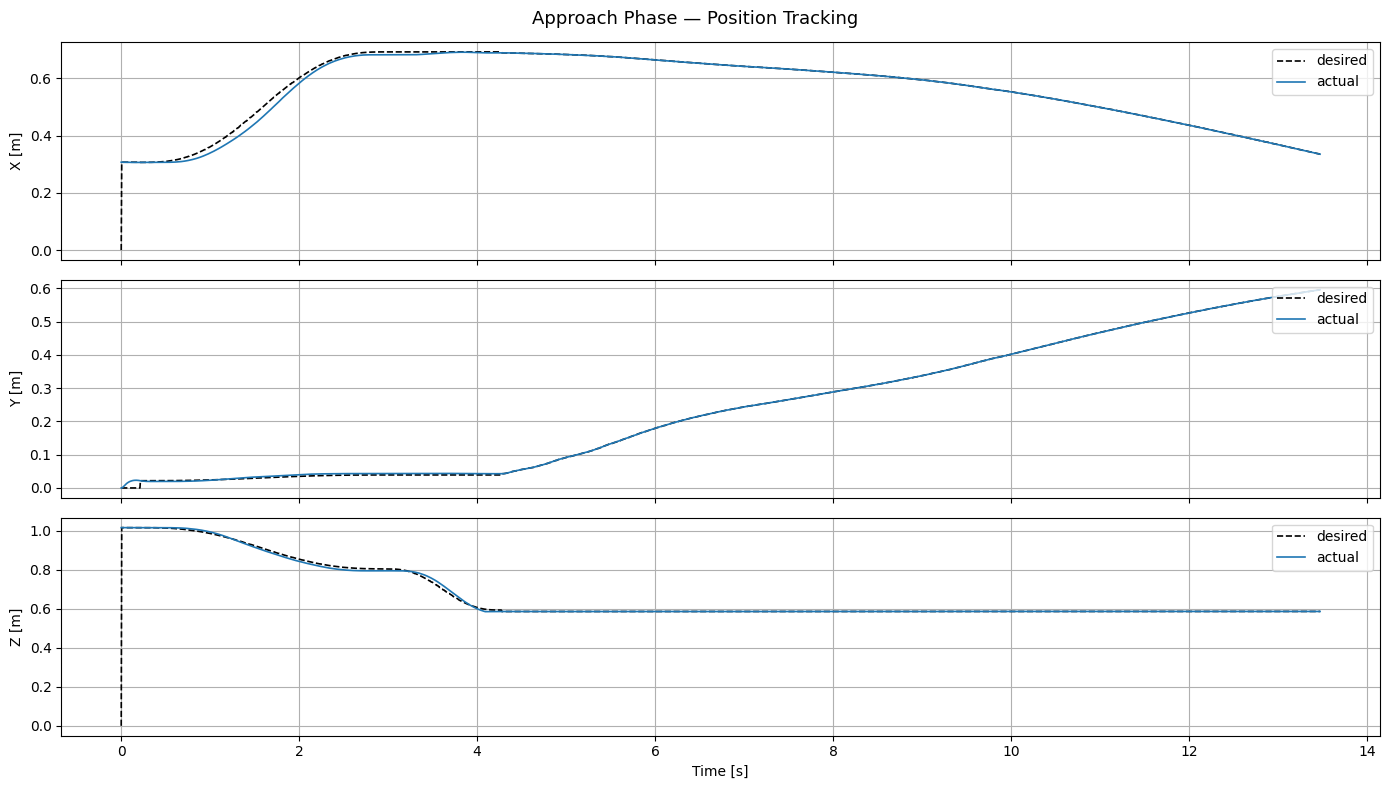

In [66]:
ctrl = bundles['ctrl_arm']
time = t(ctrl)

x_target  = np.array(ctrl['x_target'])   # (N, 7) — pos(3) + quat(4)
x_current = np.array(ctrl['x_current'])  # (N, 7) — pos(3) + quat(4)
p_des = x_target[:, :3]
p_act = x_current[:, :3]

labels = ['X', 'Y', 'Z']
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Approach Phase — Position Tracking', fontsize=13)

for i, ax in enumerate(axes):
    ax.plot(time, p_des[:, i], 'k--', label='desired', linewidth=1.2)
    ax.plot(time, p_act[:, i], label='actual', linewidth=1.2)
    ax.set_ylabel(f'{labels[i]} [m]')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

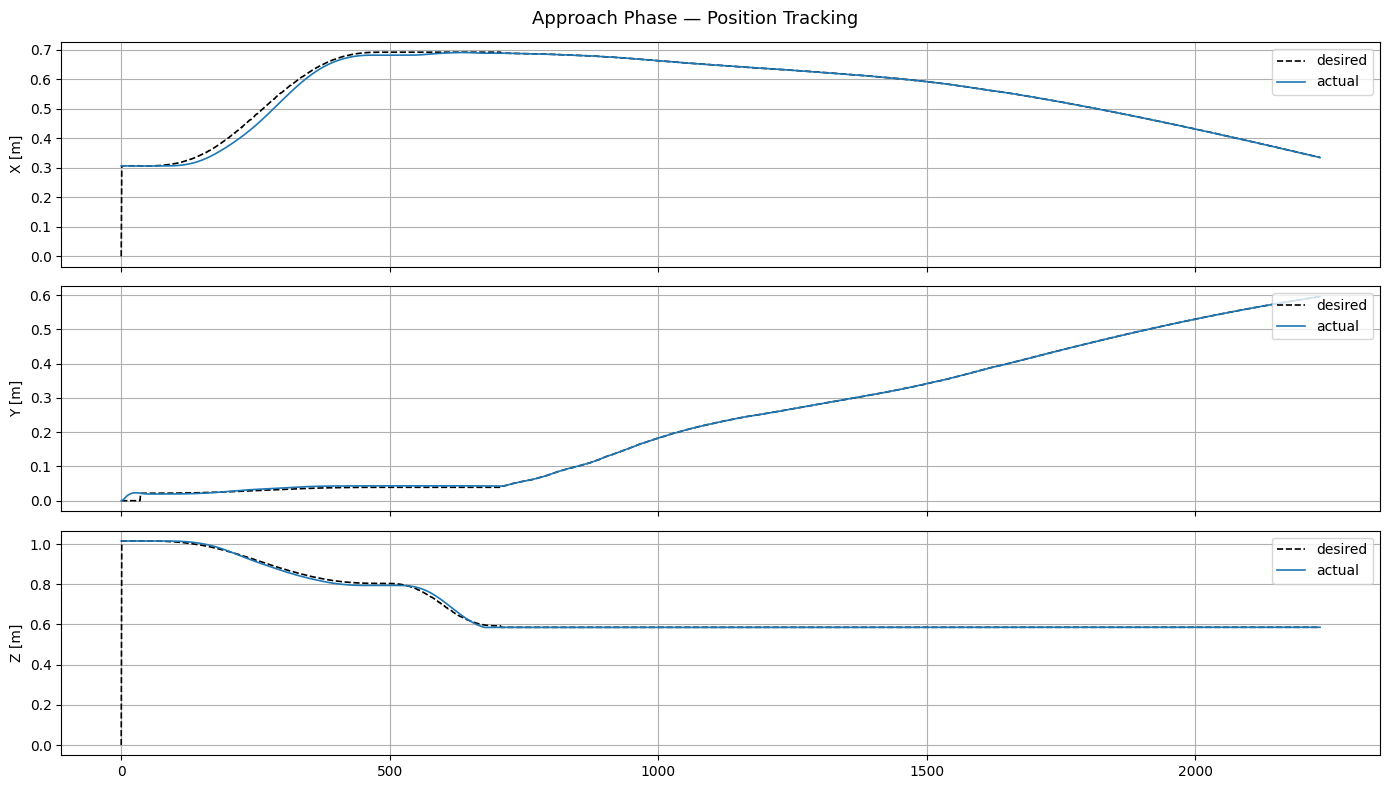

In [67]:
ctrl = bundles['ctrl_arm']
time = t(ctrl)

x_target  = np.array(ctrl['x_target'])   # (N, 7) — pos(3) + quat(4)
x_current = np.array(ctrl['x_current'])  # (N, 7) — pos(3) + quat(4)
p_des = x_target[:, :3]
p_act = x_current[:, :3]

labels = ['X', 'Y', 'Z']
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Approach Phase — Position Tracking', fontsize=13)

for i, ax in enumerate(axes):
    ax.plot(p_des[:, i], 'k--', label='desired', linewidth=1.2)
    ax.plot(p_act[:, i], label='actual', linewidth=1.2)
    ax.set_ylabel(f'{labels[i]} [m]')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

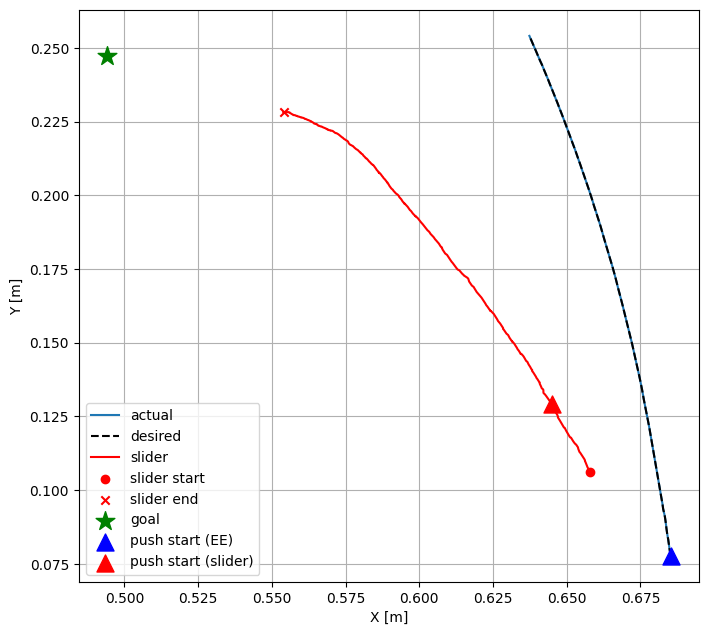

In [68]:
start, stop = 800, 1200

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(p_act[start:stop, 0], p_act[start:stop, 1], label='actual')
ax.plot(p_des[start:stop, 0], p_des[start:stop, 1], 'k--', label='desired')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')

box = bundles['box']
box_pos = np.array(box['pos'])  # (N, 3)

ax.plot(box_pos[:, 0], box_pos[:, 1], 'r-', label='slider')
ax.scatter(*box_pos[0, :2], c='r', marker='o', zorder=5, label='slider start')
ax.scatter(*box_pos[-1, :2], c='r', marker='x', zorder=5, label='slider end')

target = bundles['target']
goal_pos = np.array(target['pos'])[0, :2] 
ax.scatter(*goal_pos, c='g', marker='*', s=200, zorder=5, label='goal')

ax.scatter(p_act[start, 0], p_act[start, 1], 
           c='b', marker='^', s=150, zorder=5, label='push start (EE)')
ax.scatter(box_pos[start, 0], box_pos[start, 1],
           c='r', marker='^', s=150, zorder=5, label='push start (slider)')

ax.legend()
ax.set_aspect('equal')

plt.show()

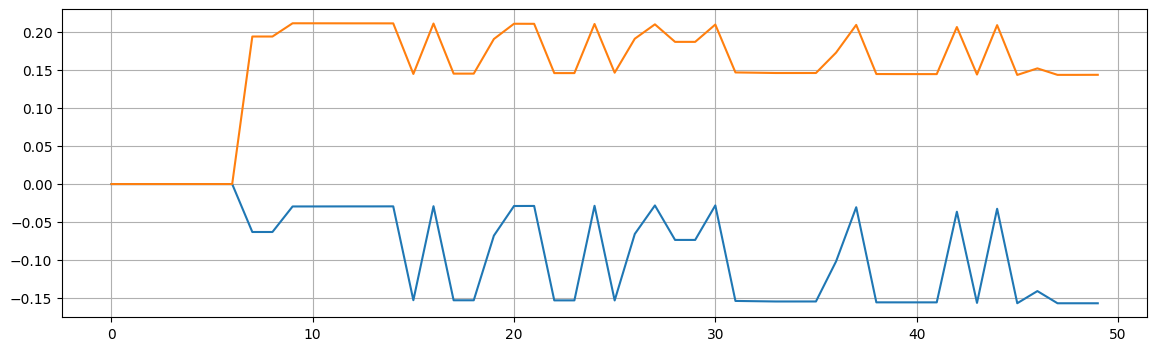

In [69]:
ctrl = bundles['ctrl_arm']
xd_target = ctrl.get("xd_target")[:,:2]

plt.plot(xd_target[700:750,:])

plt.show()

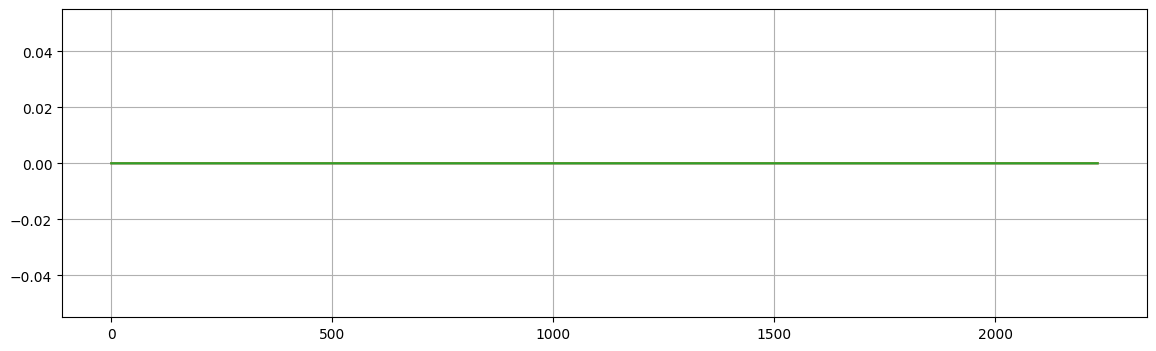

In [70]:
ctrl = bundles['ctrl_arm']
f_ext = ctrl.get("f_ext")[:,:3]

plt.plot(f_ext)
plt.show()